In [8]:
import numpy as np
import matplotlib.pyplot as plt

#Required to import shared functions
import sys
sys.path.append('../src/')

#Required to save figures
import os

In [2]:
#Importing shared .py file containing shared functions
import utils
import importlib
importlib.reload(utils)

<module 'utils' from '/mnt/windows/Linux_Wind_Shared/GalaxyFormation_FullProject/Notebooks/../src/utils.py'>

In [3]:
#Importing Cosmological Pars and original power spectrum functions

from utils import h, Om_m, Om_b, Om_lambda, rho_c, delta_c, sigma8_obs, n, z_range, f_b, H0, H, W, T, D, P, Pi, sigma_R, sigma_M, A, rho_0

## Original Power Spectrum

In [117]:
# Evaluate and print the normalization factor
R8 = 8/h      # units of Mpc, evaluating sigma_8 at this radius

A = sigma8_obs/sigma_R(R8,0,np.inf) #Normalization to observed sigma_8 value
print(R8)
print(sigma_R(R8,0,1000))
print(f"Normalization factor A for sigma_8 = {sigma8_obs} is A = {A}")

11.940298507462686
0.00022314453983950192
Normalization factor A for sigma_8 = 0.811 is A = 3634.415615023862


In [87]:
"""

#Defining a test to check the original integrator is working

def W_test(k,R):
    kR = k*R
    return kR

def P_test(k,z,cutoff=np.inf):
    if k<=cutoff:    
        return Pi_test(k)*T_test(k)**2
    else:
        return 0

# Primordial power spectrum (un-normalised)
def Pi_test(k):
    return k**n

# Transfer Function
def T_test(k):
    return k

# Variance of smoothed density field (wrt radius, R)
def sigma_R_test(R,z=0,cutoff=1000):    
    # Integrand for the variance calculation
    def integral(k):
        return P_test(k,z,cutoff) * k**2 * W_test(k,R)**2 / (2 * np.pi**2)
    
    sigma2, _ = quad(integral, 0, np.inf, limit=500, epsabs=1e-5, epsrel=1e-5)
    return np.sqrt(sigma2)

test_val = sigma_R_test(8)

print(test_val)

integrator_tester = np.sqrt(64 / (2 * np.pi ** 2) * (1000) ** 7.965 / 7.965)

print(integrator_tester)

"""

'\n\n#Defining a test to check the original integrator is working\n\ndef W_test(k,R):\n    kR = k*R\n    return kR\n\ndef P_test(k,z,cutoff=np.inf):\n    if k<=cutoff:    \n        return Pi_test(k)*T_test(k)**2\n    else:\n        return 0\n\n# Primordial power spectrum (un-normalised)\ndef Pi_test(k):\n    return k**n\n\n# Transfer Function\ndef T_test(k):\n    return k\n\n# Variance of smoothed density field (wrt radius, R)\ndef sigma_R_test(R,z=0,cutoff=1000):    \n    # Integrand for the variance calculation\n    def integral(k):\n        return P_test(k,z,cutoff) * k**2 * W_test(k,R)**2 / (2 * np.pi**2)\n\n    sigma2, _ = quad(integral, 0, np.inf, limit=500, epsabs=1e-5, epsrel=1e-5)\n    return np.sqrt(sigma2)\n\ntest_val = sigma_R_test(8)\n\nprint(test_val)\n\nintegrator_tester = np.sqrt(64 / (2 * np.pi ** 2) * (1000) ** 7.965 / 7.965)\n\nprint(integrator_tester)\n\n'

In [183]:
k_range = np.linspace(1, 1000) #spatial modes from large scale (k=1) to small scale (k=999)
P_old_test_vals = np.zeros((len(z_range), len(k_range))) #Power spectrum array for various k vals at various z

for i in range(len(z_range)):
    for j in range(len(k_range)):
        P_old_test_vals[i][j] = A * P(k_range[j], z_range[i], cutoff = np.inf) #No upper cutoff in k placed, though it is cutoff by input

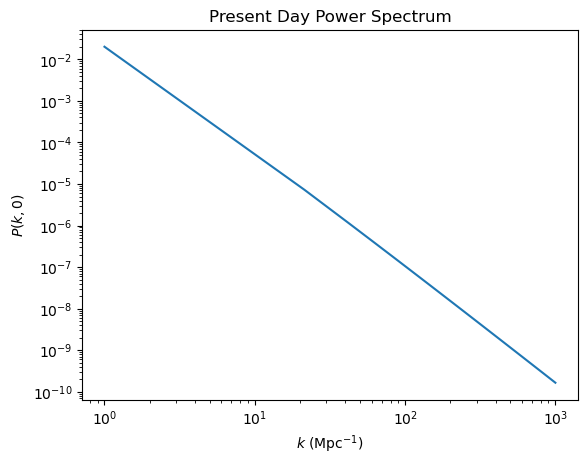

In [184]:
plt.loglog(k_range, P_old_test_vals[0], label = r'$A_\text{G}=0$')
plt.xlabel(r'$k$ (Mpc$^{-1}$)')
plt.ylabel(r'$P(k,0)$')
plt.title(r'Present Day Power Spectrum')

"""

save_dir = "/mnt/windows/Linux_Wind_Shared/GalaxyFormation_FullProject/Figures/EnhancedPowerSpectrum"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "Original_PresentDay_PS.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

## New Power Spectrum

In [185]:
#"""
#Defined originally for quad integrator

def P_new(k, z, A_G, k_mean, k_std, cutoff=np.inf): #Power spectrum evolution, no upper cutoff in k
    if k<=cutoff:    
        return Pi_new(k, A_G, k_mean, k_std)*(T(k)*D(z))**2
    else:
        return 0
#"""

# Primordial matter power spectrum (un-normalised)
def Pi_new(k, A_G, k_mean, k_std):
    #Enhancement in form of localized gaussian at large k
    return k ** n * (1 + A_G * (1 / (k_std * np.sqrt(2 * np.pi))) * np.e ** (-1 / 2 * ((k - k_mean) / k_std) ** 2))

In [186]:
#Gaussian Parameters

A_G_val = 10**4
k_mean_val = np.array([30, 100, 300])
k_std_val = 50

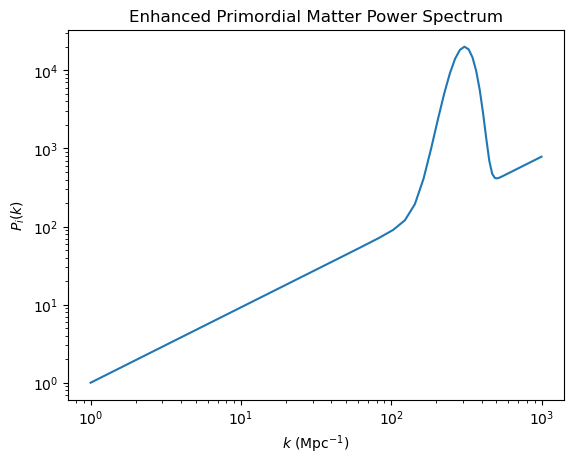

In [187]:
Pi_new_test_vals = Pi_new(k_range, A_G_val, k_mean_val[2], k_std_val)

plt.loglog(k_range, Pi_new_test_vals)
plt.xlabel(r'$k$ (Mpc$^{-1}$)')
plt.ylabel(r'$P_i(k)$')
plt.title(r'Enhanced Primordial Matter Power Spectrum')

"""

save_dir = "/mnt/windows/Linux_Wind_Shared/GalaxyFormation_FullProject/Figures/EnhancedPowerSpectrum"

# Create folder if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Full path to output file
save_path = os.path.join(save_dir, "EnhancedPrimordial_PS.png")

# Save figure
plt.savefig(save_path, dpi=300, bbox_inches="tight")

"""

plt.show()

In [188]:
def P_new2(k, z, A_G, k_mean, k_std, cutoff=np.inf): #Defining new PS compatible with simpsons integration

    P = Pi_new(k, A_G, k_mean, k_std) * (T(k)*D(z))**2

    return np.where(k <= cutoff, P, 0.0) #Return P only for k vals below cutoff, all other P(k) set to 0.0

In [189]:
from scipy.integrate import quad #Quad integration method

In [190]:
# Variance of smoothed density field (wrt radius, R), defined for P_new to check quad integrator
def sigma_R_new(R, A_G, k_mean, k_std, z=0, cutoff=np.inf):    
    # Integrand for the variance calculation
    def integral(k):
        return P_new(k, z, A_G, k_mean, k_std, cutoff) * k**2 * W(k,R)**2 / (2 * np.pi**2)
    
    sigma2, _ = quad(integral, 0, np.inf, limit=1000, epsabs=1e-5, epsrel=1e-5)
    return np.sqrt(sigma2)


# Variance of smoothed density field (wrt mass of region, M)
def sigma_M_new(M, A_G, k_mean, k_std, z=0, cutoff=np.inf):
    # Compute R corresponding to the mass M
    R = (3 * M / (4 * np.pi * rho_0))**(1/3)
    
    return sigma_R_new(R,A_G, k_mean, k_std, z, cutoff)

In [213]:
#Plotting the integrand as test

def sigma_R_new_integrand(k, z, A_G, k_mean, k_std, cutoff, R):
    return P_new(k, z, A_G, k_mean, k_std, cutoff) * k ** 2 * W(k, R) ** 2 / (2 * np.pi ** 2)

R_arr = (M_range_new / (Om_m * rho_c) * 3 / (4 * np.pi)) ** (1 / 3)

sigma_R_new_vals = np.zeros((len(R_arr), len(k_range)))

for i in range(len(R_arr)):
    for j in range(len(k_range)):
        sigma_R_new_vals[i, j] = sigma_R_new_integrand(k_range[j], 0, A_G_val, k_mean_val[2], k_std_val, np.inf, R_arr)[i]

In [255]:
R_arr[700]
M_range_new[155]

np.float64(303.72635797033115)

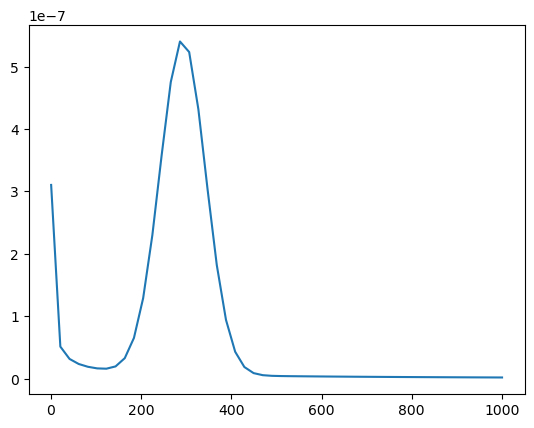

In [256]:
plt.plot(k_range, sigma_R_new_vals[155])

In [191]:
"""

#Testing the integrator

from scipy.special import gamma, gammainc #importing gamma and incomplete gamma functions for evaluating integral

def P_new_test(k, z, A_G, k_mean, k_std, cutoff=np.inf): #Power spectrum evolution, no upper cutoff in k
    if k<=cutoff:    
        return Pi_new_test(k, A_G, k_mean, k_std)*(T_test(k))**2
    else:
        return 0

# Primordial matter power spectrum (un-normalised)
def Pi_new_test(k, A_G, k_mean, k_std):
    #Enhancement in form of localized gaussian at large k
    return k ** n * (1 + A_G * (1 / (k_std * np.sqrt(2 * np.pi))) * np.e ** (-1 / 2 * ((k - k_mean) / k_std) ** 2))

def W_test(k,R):
    kR = k*R
    return kR
    
# Transfer Function
def T_test(k):
    return k

A_G_val_test = 10**4
k_mean_val_test = 0
k_std_val_test = 50

def sigma_R_new_test(R, A_G, k_mean, k_std, z=0, cutoff=1000):    
    # Integrand for the variance calculation
    def integral(k):
        return P_new_test(k, z, A_G, k_mean, k_std, cutoff) * k**2 * W_test(k,R)**2 / (2 * np.pi**2)
    
    sigma2, _ = quad(integral, 0, np.inf, limit=1000, epsabs=1e-5, epsrel=1e-5)
    return np.sqrt(sigma2)

test_val = sigma_R_new_test(8, A_G_val_test, k_mean_val_test, k_std_val_test)

print(test_val)

integrator_tester = np.sqrt((2**((0.965-1)/2)
    * 50**(0.965+1)
    * gamma((0.965+1)/2)
    * gammainc((0.965+1)/2, 1000**2/(2*50**2)) + 1000 ** 7.965 / 7.965) * 64 / (2 * np.pi ** 2))

print(integrator_tester)

"""

'\n\n#Testing the integrator\n\nfrom scipy.special import gamma, gammainc #importing gamma and incomplete gamma functions for evaluating integral\n\ndef P_new_test(k, z, A_G, k_mean, k_std, cutoff=np.inf): #Power spectrum evolution, no upper cutoff in k\n    if k<=cutoff:    \n        return Pi_new_test(k, A_G, k_mean, k_std)*(T_test(k))**2\n    else:\n        return 0\n\n# Primordial matter power spectrum (un-normalised)\ndef Pi_new_test(k, A_G, k_mean, k_std):\n    #Enhancement in form of localized gaussian at large k\n    return k ** n * (1 + A_G * (1 / (k_std * np.sqrt(2 * np.pi))) * np.e ** (-1 / 2 * ((k - k_mean) / k_std) ** 2))\n\ndef W_test(k,R):\n    kR = k*R\n    return kR\n\n# Transfer Function\ndef T_test(k):\n    return k\n\nA_G_val_test = 10**4\nk_mean_val_test = 0\nk_std_val_test = 50\n\ndef sigma_R_new_test(R, A_G, k_mean, k_std, z=0, cutoff=1000):    \n    # Integrand for the variance calculation\n    def integral(k):\n        return P_new_test(k, z, A_G, k_mean, k_std

In [192]:
from scipy.integrate import simpson #Importing simpson integrator to compare with quad

In [193]:
def sigma_R_new2(R, A_G, k_mean, k_std, z=0, cutoff=np.inf): #defined for P_new2 to check simpson integrator

    logk = np.linspace(-4, 5, 20000)
    k = 10**logk

    integrand = (
        np.log(10)
        * P_new2(k, z, A_G, k_mean, k_std, cutoff)
        * k**3
        * W(k, R)**2
        / (2*np.pi**2)
    )

    sigma2 = simpson(integrand, x=logk)

    return np.sqrt(sigma2)

# Variance of smoothed density field (wrt mass of region, M)
def sigma_M_new2(M, A_G, k_mean, k_std, z=0, cutoff=np.inf):
    # Compute R corresponding to the mass M
    R = (3 * M / (4 * np.pi * rho_0))**(1/3)
    
    return sigma_R_new2(R,A_G, k_mean, k_std, z, cutoff)

In [194]:
# Evaluate and print the normalization factor using quad integrator

A_new = sigma8_obs/sigma_R_new(R8, A_G_val, k_mean_val[2], k_std_val, 0)
print(sigma_R_new(R8, A_G_val, k_mean_val[2], k_std_val))
print(f"Normalization factor A for sigma_8 = {sigma8_obs} is A = {A_new}")

0.00022314467749786558
Normalization factor A for sigma_8 = 0.811 is A = 3634.413372946157


In [195]:
#Powerspectrum using quad integrator
P_test_vals = np.zeros((len(k_mean_val), len(z_range), len(k_range)))

for p in range(len(k_mean_val)):
    for i in range(len(z_range)):
        for j in range(len(k_range)):
            P_test_vals[p, i, j] = A_new * P_new(k_range[j], z_range[i], A_G_val, k_mean_val[p], k_var_val, cutoff=np.inf)

In [196]:
# Evaluate and print the normalization factor using simpson integrator

A_new2 = sigma8_obs/sigma_R_new2(R8, A_G_val, k_mean_val[2], k_std_val, 0)
print(sigma_R_new2(R8, A_G_val, k_mean_val[2], k_std_val))
print(f"Normalization factor A for sigma_8 = {sigma8_obs} is A = {A_new2}")

0.0002231320419130435
Normalization factor A for sigma_8 = 0.811 is A = 3634.6191835417962


In [197]:
#Powerspectrum using simpson integrator
P_test_vals2 = np.zeros((len(k_mean_val), len(z_range), len(k_range)))

for p in range(len(k_mean_val)):
    for i in range(len(z_range)):
        for j in range(len(k_range)):
            P_test_vals2[p, i, j] = A_new2 * P_new2(k_range[j], z_range[i], A_G_val, k_mean_val[p], k_var_val, cutoff=np.inf)

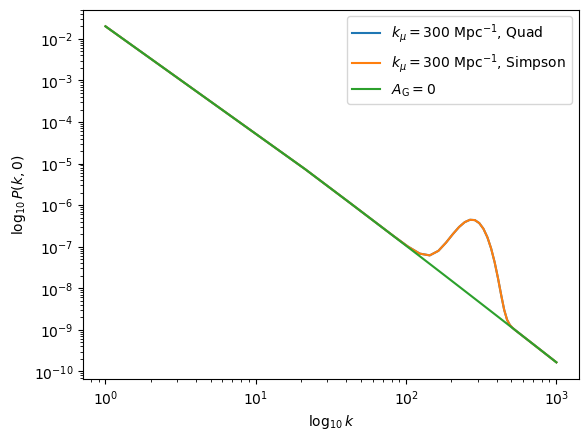

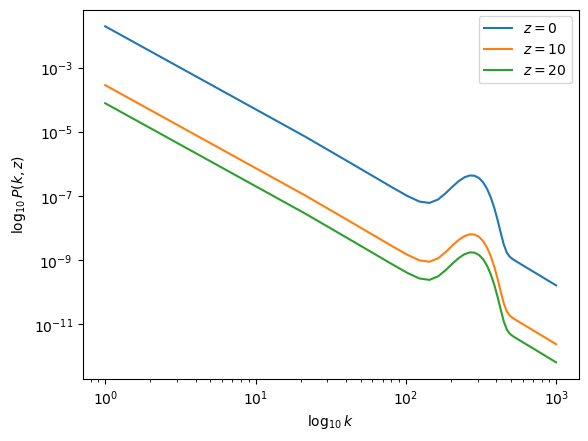

In [198]:
#Plotting Quad integrator results

plt.loglog(k_range, P_test_vals[2][0], label = r'$k_\mu=300$ Mpc$^{-1}$, Quad')
plt.loglog(k_range, P_test_vals2[2][0], label = r'$k_\mu=300$ Mpc$^{-1}$, Simpson')

plt.loglog(k_range, P_old_test_vals[0], label = r'$A_\text{G}=0$')

plt.xlabel(r'$\log_{10}k$')
plt.ylabel(r'$\log_{10}P(k,0)$')

plt.legend()
plt.show()

#const A_G, const k_\mu

plt.loglog(k_range, P_test_vals[2][0], label = r'$z=0$')
plt.loglog(k_range, P_test_vals[2][49], label = r'$z=10$')
plt.loglog(k_range, P_test_vals[2][99], label = r'$z=20$')

plt.xlabel(r'$\log_{10}k$')
plt.ylabel(r'$\log_{10}P(k,z)$')

plt.legend()
plt.show()

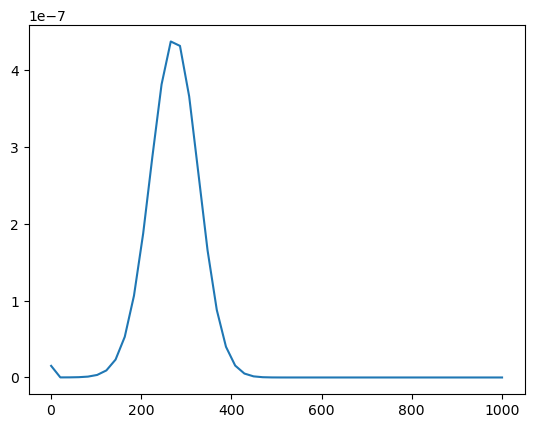

In [211]:
plt.plot(k_range, P_test_vals[2][0] - P_old_test_vals[0])
#plt.xlim(0,50)

In [200]:
M_range_new = np.logspace(0, 16, 1000)

In [201]:
#Old powerspectrum sigma for new mass range

y = [A*sigma_M(M,0,10**10) for M in M_range_new]
#y_1 = [A*sigma_M(M,0,1) for M in M_range_new]
#y_10 = [A*sigma_M(M,0,10) for M in M_range_new]

In [202]:
y_new = [A_new * sigma_M_new(M, A_G_val, k_mean_val[2], k_std_val, z=0, cutoff = 10**10) for M in M_range_new]
#y_1_new = [A_new * sigma_M_new(M, A_G_val, k_mean_val[2], k_var_val, z=0, cutoff = 1) for M in M_range_new]
#y_10_new = [A_new * sigma_M_new(M, A_G_val, k_mean_val[2], k_var_val, z=0, cutoff = 10) for M in M_range_new]

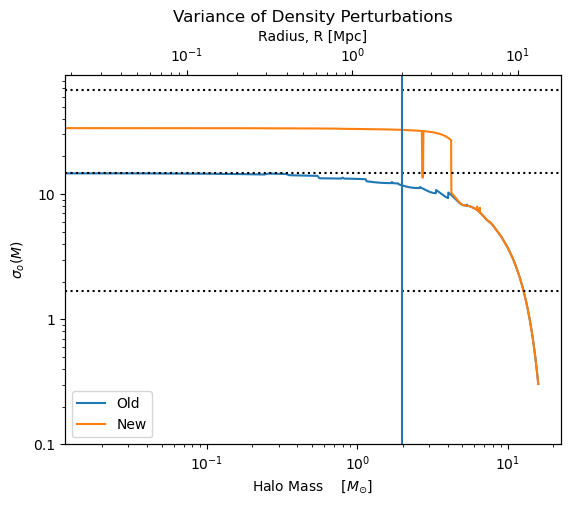

In [251]:
plt.figure()

plt.plot(np.log10(M_range_new), y,label="Old")
#plt.plot(M_range, y_1,label="Cutoff at $k = 1 \ Mpc^{-1}$", ls='--')
#plt.plot(M_range, y_10,label="Cutoff at $k = 10 \ Mpc^{-1}$" , ls='-.')

plt.plot(np.log10(M_range_new), y_new,label="New")

plt.axhline(y=delta_c/D(z=0),ls=':',color='k')
plt.axhline(y=delta_c/D(z=10),ls=':',color='k')
plt.axhline(y=delta_c/D(z=50),ls=':',color='k')

#plt.text(9e14,delta_c/D(z=0)-0.1, "$\delta_c \ (z=0)$", va='top',ha='right',fontsize=13)
#plt.text(9e14,delta_c/D(z=2)-0.2, "$\delta_c \ (z=2)$", va='top',ha='right',fontsize=13)
#plt.text(9e14,delta_c/D(z=5)-0.3, "$\delta_c \ (z=5)$", va='top',ha='right',fontsize=13)

plt.xscale('log')
plt.yscale('log')
#plt.xlim(1e15,1e16)
#plt.ylim(1,2)

plt.xlabel("Halo Mass $\quad [M_{\odot}]$")
plt.ylabel("$\sigma_o(M)$")

plt.yticks([1e-1,1,1e1],["0.1",1,"10"])
plt.legend()

# Duplicate x-axis at the top
ax_top = plt.gca().twiny()                      # Get current axis and create a twin x-axis

ax_top.set_xlim(6,15)                           # Matching bottom axis range
R_range = [(3 * 10**M / (4 * np.pi * rho_0))**(1/3) for M in range(6,16)]
ax_top.set_xticks(R_range)
ax_top.set_xticklabels([f"{R}" for R in R_range])   
ax_top.set_xlabel("Radius, R [Mpc]")
ax_top.set_xscale('log')

# plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.title("Variance of Density Perturbations")

plt.axvline(2)

plt.show()

In [204]:
from utils import poly_fit

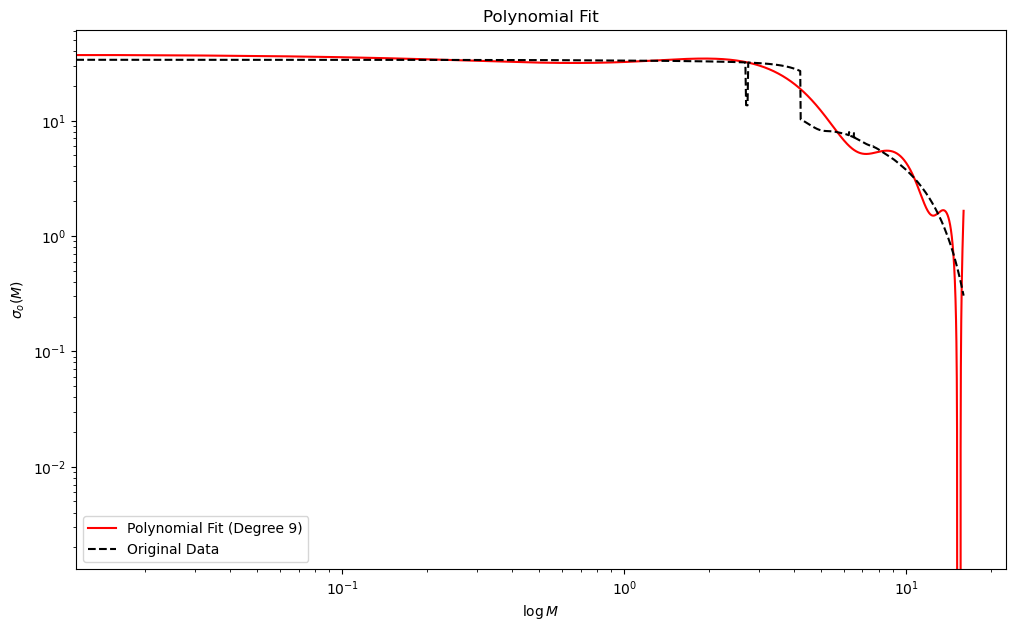

In [205]:
degree = 9
logM_new = np.log10(M_range_new)
sigma_range_new = [A_new*sigma_M_new(M, A_G_val, k_mean_val[2], k_var_val) for M in M_range_new]
cof = poly_fit(logM_new,y_new,degree,plot=True)

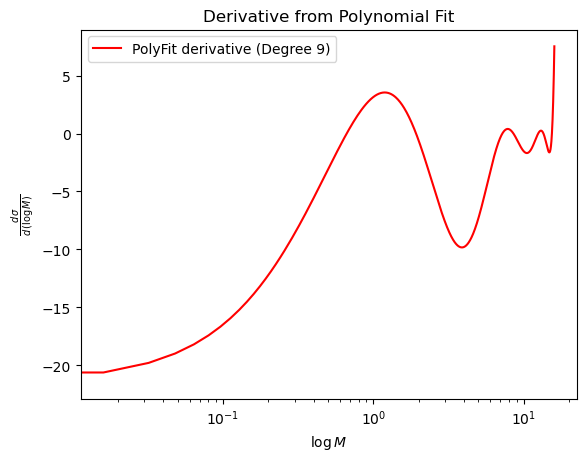

In [206]:
# Evaluating the derivative 

d_cof = np.polyder(cof)

fit_deriv = np.poly1d(d_cof)

# plotting the log-derivative
plt.plot(logM_new, fit_deriv(logM_new), 'r', lw=1.5, label=f'PolyFit derivative (Degree {degree})')
plt.xscale('log')
plt.xlabel(r'$\log M $')
plt.ylabel(r'$ \frac{d\,\sigma}{d\,(\log M)}$')
plt.legend()
plt.title('Derivative from Polynomial Fit')
plt.show()

In [207]:
from utils import PS_MassFunc

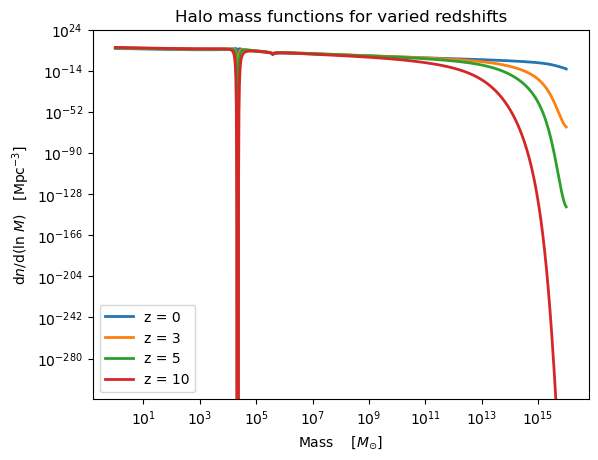

In [208]:
# Plotting abundance of DM halo, n(M,z):
redshifts = [0,3, 5,10]

plt.figure()

for z in redshifts:
    dn_dlogM = [PS_MassFunc(M, z)*(rho_0/M) for M in M_range_new]
    plt.plot(M_range_new, dn_dlogM, lw=2 , label=f"z = {z}")
    
# Plotting mass fraction of halos
plt.xscale('log')
plt.yscale('log')
#plt.xlim(1e6,1e15)
#plt.ylim(1e-8,1e4)

plt.xlabel("Mass $\quad [M_{\odot}]$")
plt.ylabel("d$n/$d$(\ln\,M) \quad $[Mpc$^{-3}$]")
plt.title("Halo mass functions for varied redshifts")

#plt.axvline(2.5 * 10**(10), color = r'firebrick', ls = '--')

plt.legend()
plt.show()